# Agrupando colores

Vamos a crear imagenes con una cantidad fija de colores

#### 1. Importa las librerias
Vamos a necesitar `KMeans` de `sklearn.cluster`, `imread` de `matplotlib.image`, `matplotlib.pyplot` y `numpy`


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

#### 2. Lee una imagen
Utiliza alguna foto que tengas en tu ordenador y leela con la función `imread`

Consejo: utiliza una imagen pequeña si no quieres tardar una eternidad en que se ejecute el kmeans

In [4]:
image = plt.imread('data/TGHN_Logo_Main.png')
image.shape

(281, 600, 4)

Muestra la imagen para ver que se ha cargado bien

In [5]:
image.size/3

224800.0

In [6]:
764*1499

1145236

In [7]:
image

array([[[0.88235295, 0.88235295, 0.88235295, 0.6745098 ],
        [0.88235295, 0.88235295, 0.88235295, 0.8666667 ],
        [0.88235295, 0.88235295, 0.88235295, 0.8666667 ],
        ...,
        [0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        ]],

       [[0.88235295, 0.88235295, 0.88235295, 0.7764706 ],
        [0.88235295, 0.88235295, 0.88235295, 1.        ],
        [0.88235295, 0.88235295, 0.88235295, 1.        ],
        ...,
        [0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        ]],

       [[0.88235295, 0.88235295, 0.88235295, 0.7764706 ],
        [0.88235295, 0.88235295, 0.88235295, 1.        ],
        [0.88235295, 0.88235295, 0.88235295, 1.        ],
        ...,
        [0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.      

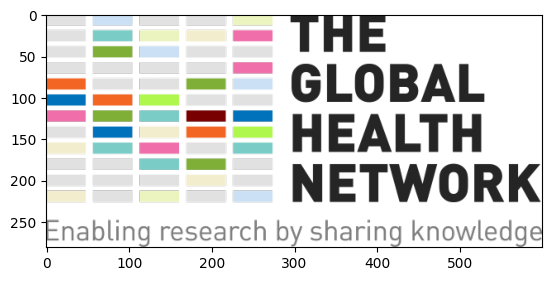

In [8]:
plt.imshow(image)

#### 3. Modifica la estructura de la imagen
Queremos que cada pixel sea una observación por lo que tenemos que transformar nuestra imagen de un vector de forma (alto, ancho, color) a (alto x ancho, color). Color será siempre 3, que son los tres canales de los colores.

Ej: (300, 400, 3) -> (120000, 3)

In [9]:
X = image.reshape(-1,3)
X.shape

(224800, 3)

#### 4. K-means
Haz un k-means con la imagen de entrada (Con la nueva forma que le hemos dado). K será el número de colores que quieras que tenga tu imagen de salida

In [10]:
k = 10
kmeans = KMeans(n_clusters=k, n_init=10, random_state=10).fit(X)

#### 5. Sustituye cada valor por su centroide

Una vez hemos entrenado el kmeans entre otros parametros de salida tiene `cluster_centers_` y `labels_`. Utilizlos para crear una nueva imagen (recuerda que las imagenes simplemente son vectores numéricos) en la que cada pixel se sustituye por su centroide correspondiente.

In [11]:
kmeans.labels_

array([6, 6, 6, ..., 0, 0, 0], shape=(224800,), dtype=int32)

In [12]:
kmeans.labels_.shape

(224800,)

In [13]:
kmeans.cluster_centers_

array([[3.0910969e-04, 3.6090612e-05, 4.7287345e-04],
       [7.9569542e-01, 9.4374245e-01, 3.5424140e-01],
       [4.4044164e-01, 5.2550709e-01, 4.0255582e-01],
       [1.4977622e-01, 9.8361135e-01, 1.9021803e-01],
       [1.4235024e-01, 1.6453695e-01, 9.5651424e-01],
       [3.7733239e-01, 7.6560932e-01, 8.9444852e-01],
       [9.0052056e-01, 9.0358675e-01, 9.1079319e-01],
       [9.0902853e-01, 3.9819098e-01, 7.6753724e-01],
       [9.6936941e-01, 1.6394204e-01, 1.5609856e-01],
       [1.5793785e-01, 1.4174907e-01, 1.5419735e-01]], dtype=float32)

In [14]:
segmented_img = kmeans.cluster_centers_[kmeans.labels_]

In [15]:
kmeans.cluster_centers_[kmeans.labels_]

array([[9.0052056e-01, 9.0358675e-01, 9.1079319e-01],
       [9.0052056e-01, 9.0358675e-01, 9.1079319e-01],
       [9.0052056e-01, 9.0358675e-01, 9.1079319e-01],
       ...,
       [3.0910969e-04, 3.6090612e-05, 4.7287345e-04],
       [3.0910969e-04, 3.6090612e-05, 4.7287345e-04],
       [3.0910969e-04, 3.6090612e-05, 4.7287345e-04]],
      shape=(224800, 3), dtype=float32)

In [16]:
kmeans.cluster_centers_[kmeans.labels_].shape

(224800, 3)

In [17]:
kmeans.labels_.shape

(224800,)

#### 6. Modifica la estructura de la imagen
Para trabajar con el k-means requeriamos que la imagen original fuese un solo vector, ahora como queremos volver a tener la imagen para volver mostrarla debemos hacer el proceso inverso a el paso 3. (Si has guardado la forma de la imagen original te será más facil hacer este paso)

In [18]:
image.shape

(281, 600, 4)

In [19]:
segmented_img = segmented_img.reshape(image.shape)

#### 7. Muestra y guarda en tu ordenador la imagen resultante

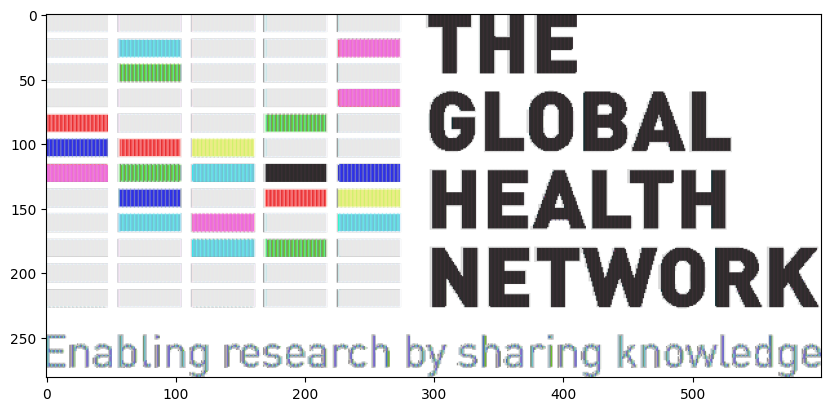

In [21]:
fig = plt.figure(figsize=(10,10))
plt.imshow(segmented_img)

In [26]:
fig.savefig("data/image2.png")

#### 8. Crea una función
Crea una función que tenga como argumentos de entrada una imagen, el numero de colores que quieres que tenga, y si se quiere guardar o mostrar por pantalla

In [30]:
def cluster_colors(image, n_colores, save=False):
    image = plt.imread(image)
    X = image.reshape(-1,3)
    kmeans = KMeans(n_clusters=n_colores).fit(X)
    segmented_img = kmeans.cluster_centers_[kmeans.labels_]
    fig = plt.figure(figsize=(10,10))
    plt.imshow(segmented_img.reshape(image.shape))

    if save:
        fig.savefig("mi_imagen.png")

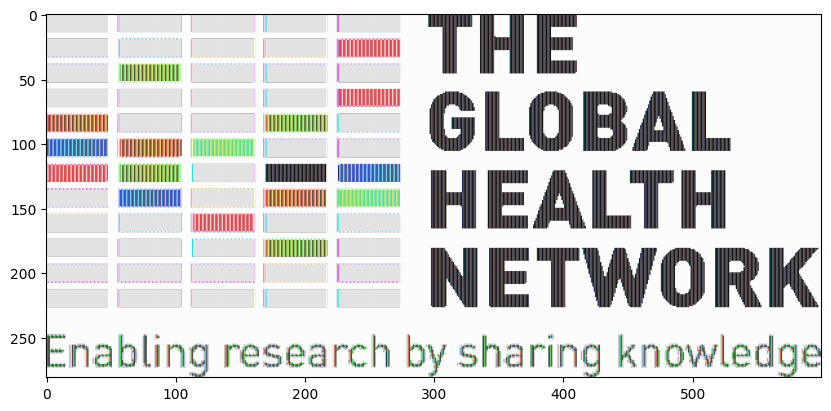

In [ ]:
cluster_colors('data/TGHN_logo_main.png', 5)
## compresion de la imagen con perdida de informacion. Ocupará menos tamaño que la original.